<a href="https://colab.research.google.com/github/gabrielcord/recpad20252/blob/main/Classifica%C3%A7%C3%A3o_de_Tipos_de_Personalidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Tipos de Personalidade

**Aluno:** Gabriel Cordeiro

**Disciplina:** Reconhecimento de Padrões

**Semestre:** 2025/2

## 1. Introdução

### 1.1. Descrição
Trabalho de consolidação de conteúdo da disciplina Reconhecimento de Padrões, semestre 2025/2. Elaborado com base na seguinte competição do Kaggle: [Predict the Introverts from the Extroverts](https://www.kaggle.com/competitions/playground-series-s5e7).

### 1.2. Objetivo
Prever se uma pessoa é **Introvertida** ou **Extrovertida**, considerando seu comportamento social e traços de sua personalidade.

### 1.3. Características

| Nome             | Descrição                                     | Valores Possíveis        |
|----------------------------|-----------------------------------------------|--------------------------|
| `Time_spent_Alone`         | Horas gastas sozinho diariamente              | 0–11                     |
| `Stage_fear`               | Tem medo de palco                          | Yes/No                   |
| `Social_event_attendance`  | Frequência de eventos sociais                 | 0–10                     |
| `Going_outside`            | Frequência de saídas de casa                  | 0–7                      |
| `Drained_after_socializing`| Sentimento de esgotamento após socializar     | Yes/No                   |
| `Friends_circle_size`      | Número de amigos próximos                     | 0–15                     |
| `Post_frequency`           | Frequência de postagens em redes sociais      | 0–10                     |
| `Personality`              | Variável-alvo                                 | Extrovert/Introvert      |


### 1.4. Download dos arquivos

In [1]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

In [2]:
!kaggle competitions download -q -c playground-series-s5e7

In [3]:
!unzip -q -o playground-series-s5e7.zip

## 2. Análise Exploratória


### 2.1. Estrutura e valores

In [4]:
import pandas as pd

df = pd.read_csv('train.csv', index_col='id')
df.head(7)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert
5,2.0,No,8.0,5.0,No,NaN,3.0,Extrovert
6,1.0,No,8.0,NaN,No,NaN,4.0,Extrovert


Visão geral da estrutura e dos valores presentes no conjunto de dados.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18524 entries, 0 to 18523
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           17334 non-null  float64
 1   Stage_fear                 16631 non-null  object 
 2   Social_event_attendance    17344 non-null  float64
 3   Going_outside              17058 non-null  float64
 4   Drained_after_socializing  17375 non-null  object 
 5   Friends_circle_size        17470 non-null  float64
 6   Post_frequency             17260 non-null  float64
 7   Personality                18524 non-null  object 
dtypes: float64(5), object(3)
memory usage: 1.3+ MB


São 18524 linhas e 9 colunas. Os tipos de dados são compatíveis com os descritos. Há várias colunas com dados faltantes, tanto numéricas quanto categóricas. A única coluna completamente preenchida é a variável-alvo (`Personality`).



In [6]:
numeric_features = df.select_dtypes(include=['float'])
numeric_features.describe().T

,count,mean,std,min,25%,50%,75%,max
Time_spent_Alone,17334.0,3.137764,3.003786,0.0,1.0,2.0,4.0,11.0
Social_event_attendance,17344.0,5.265106,2.753359,0.0,3.0,5.0,8.0,10.0
Going_outside,17058.0,4.044319,2.062580,0.0,3.0,4.0,6.0,7.0
Friends_circle_size,17470.0,7.996737,4.223484,0.0,5.0,8.0,12.0,15.0
Post_frequency,17260.0,4.982097,2.879139,0.0,3.0,5.0,7.0,10.0


Os valores máximos e mínimos das características numéricas estão dentro dos intervalos esperados, sem valores anômalos.



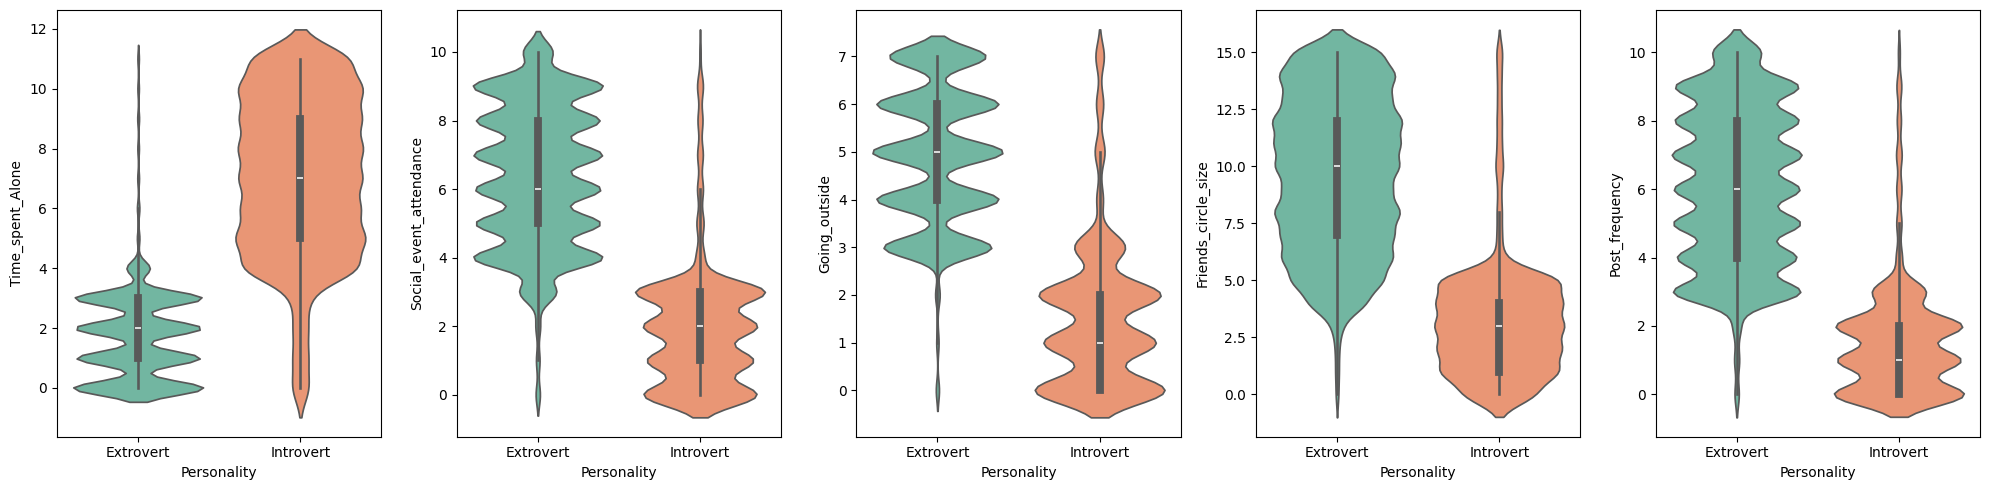

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

target_name = 'Personality'

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

for i, col in enumerate(numeric_features):
    sns.violinplot(
        data=df,
        x=target_name,
        y=col,
        hue=target_name,
        legend=False,
        ax=axes[i],
        palette="Set2",
    )

plt.tight_layout()
plt.show()

Plot da relação entre as características numéricas e a variável-alvo

In [8]:
categorical_features = df.select_dtypes(include=['object'])
categorical_features.describe().T

,count,unique,top,freq
Stage_fear,16631,2,No,12609
Drained_after_socializing,17375,2,No,13313
Personality,18524,2,Extrovert,13699


Há três variáveis categóricas, sendo uma delas a variável-alvo.

In [9]:
for col in categorical_features.columns:
    print(df[col].value_counts(normalize=False, dropna=False))

Stage_fear
No     12609
Yes     4022
NaN     1893
Name: count, dtype: int64
Drained_after_socializing
No     13313
Yes     4062
NaN     1149
Name: count, dtype: int64
Personality
Extrovert    13699
Introvert     4825
Name: count, dtype: int64


Os valores das características categóricas também estão conforme esperado, sem valores anômalos. No entanto, há valores faltantes como identificado anteriormente.

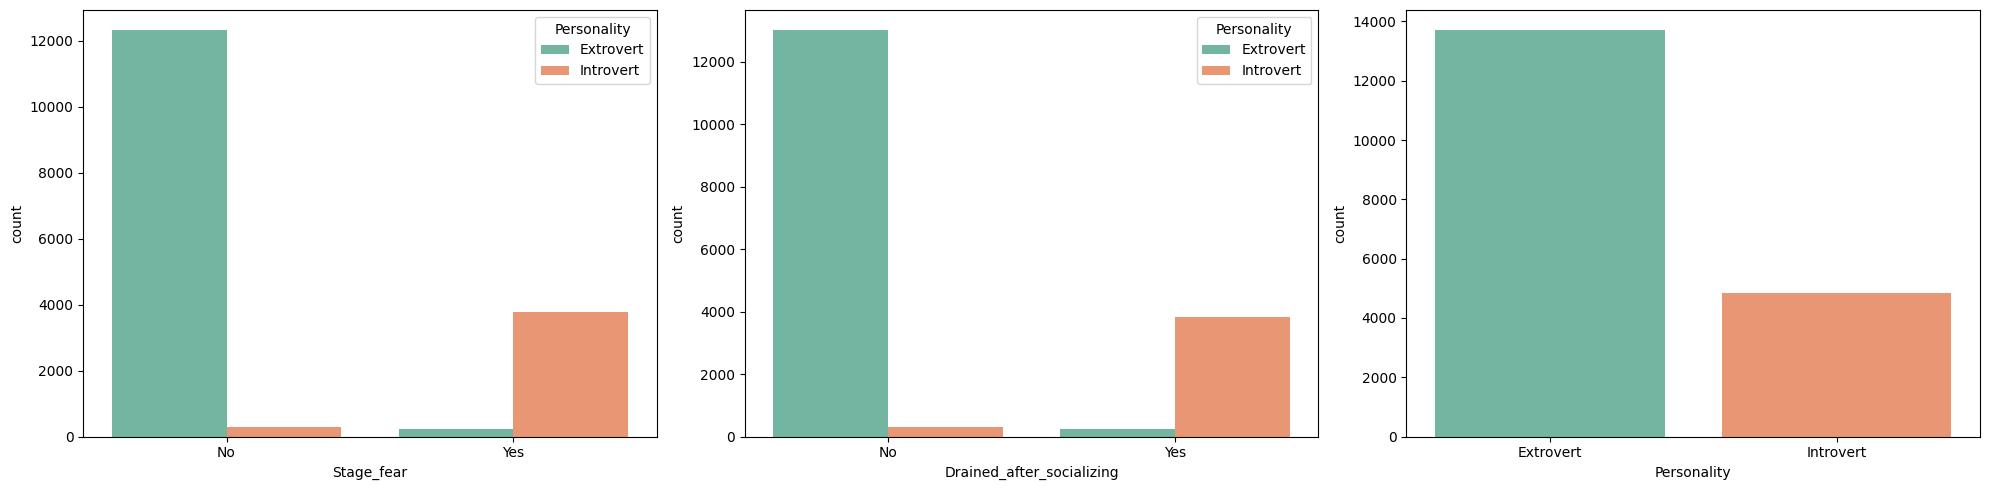

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=col,
        hue=target_name,
        ax=axes[i],
        palette="Set2"
    )

plt.tight_layout()
plt.show()

Plot da relação entre as características categóricas e a variável-alvo

In [11]:
df[target_name].value_counts(normalize=True)

,proportion
Personality,
Extrovert,0.739527
Introvert,0.260473


A proporção de extrovertidos e introvertidos é de aproximadamente 74% / 26%. Trata-se, portanto, de um dataset levemente desbalanceado.


## 3. Pré-processamento

### 3.1. Inserção de valores numéricos faltantes

In [12]:
from sklearn.impute import SimpleImputer

numeric_features_imputer = SimpleImputer(strategy='median')

Para cada dado numérico faltante, será inserido o valor da mediana da coluna naquele conjunto de treino.

### 3.2. Normalização de valores numéricos

In [13]:
from sklearn.preprocessing import MinMaxScaler

numeric_features_scaler = MinMaxScaler()

Garante que, para todas as colunas numéricas, os valores fiquem no mesmo intervalo [0, 1].

### 3.3. Inserção de valores categóricos faltantes

In [14]:
categorical_features_imputer = SimpleImputer(strategy='most_frequent')

Para cada dado categórico faltante, será inserido o valor mais frequente da coluna naquele conjunto de treino.

### 3.4. Codificação de valores categóricos

In [15]:
from sklearn.preprocessing import OneHotEncoder

categorical_features_encoder = OneHotEncoder(drop='if_binary')

Transforma as características categóricas em novas colunas com valores 0 ou 1 para cada valor disponível. No caso de características binárias, como "Yes/No", apenas uma coluna binária é mantida para evitar redundância.

### 3.5. Consolidação das transformações

In [16]:
numeric_ft_list = numeric_features.columns.tolist()
categorical_ft_list = categorical_features.columns.drop(target_name).tolist()

print(f"Lista de características numéricas: {numeric_ft_list}")
print(f"Lista de características categóricas: {categorical_ft_list}")

Lista de características numéricas: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Lista de características categóricas: ['Stage_fear', 'Drained_after_socializing']


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('numeric_imputer', numeric_features_imputer),
    ('numeric_scaler', numeric_features_scaler)
])

categorical_transformer = Pipeline(steps=[
    ('categorical_imputer', categorical_features_imputer),
    ('categorical_encoder', categorical_features_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_transformer', numeric_transformer, numeric_ft_list),
        ('categorical_transformer', categorical_transformer, categorical_ft_list),
    ],
    remainder='drop'
)

Define quais transformações serão aplicadas a quais colunas. Quaisquer colunas não incluídas aqui serão desconsideradas no treinamento. Esse objeto será utilizado dentro dos pipelines que serão definidos adiante.

### 3.6. Balanceamento de exemplos

In [18]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbalancedPipeline

random_state = 42

sampler = SMOTE(sampling_strategy='auto', random_state=random_state)

Aumenta a classe minoritária até ela ter exatamente o mesmo número de amostras da classe majoritária. Para criar um novo ponto, o SMOTE sorteia um ponto da classe minoritária, encontra K (default=5) vizinhos mais próximos dele, e cria um novo ponto em algum lugar entre o ponto original e um desses K vizinhos.

## 4. Aplicação de Algoritmos

In [19]:
X = df.drop(columns=[target_name])
y = df[target_name]

O `X` inclui todas as características com exceção da variável-alvo. O `y` inclui apenas a variável-alvo.

In [20]:
from sklearn.base import BaseEstimator

def make_pipeline(model: BaseEstimator, preprocessor: ColumnTransformer, sampler: SMOTE = None):
  if sampler:
    return ImbalancedPipeline(
      steps=[
        ('preprocessor', preprocessor),
        ('sampler', sampler),
        ('model', model),
      ],
    )

  return Pipeline(
      steps=[
        ('preprocessor', preprocessor),
        ('model', model),
      ],
    )

Cria o pipeline com ou sem balanceamento.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

Define a validação cruzada a ser utilizada com os diferentes modelos.

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

def plot_confusion_matrix(y_true, y_pred):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

  ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    ax=ax1,
    cmap='Blues',
    normalize=None,
    colorbar=True,
    values_format='d'
  )

  ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    ax=ax2,
    cmap='Blues',
    normalize='true',
    colorbar=True,
    values_format='.2%'
  )

  plt.tight_layout()
  plt.show()

Método para plotagem de matrizes de confusão com números absolutos e normalizados.

### 4.1. KNN

In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
knn = make_pipeline(KNeighborsClassifier(), preprocessor)
knn_y_pred = cross_val_predict(knn, X, y, cv=cv, n_jobs=-1)

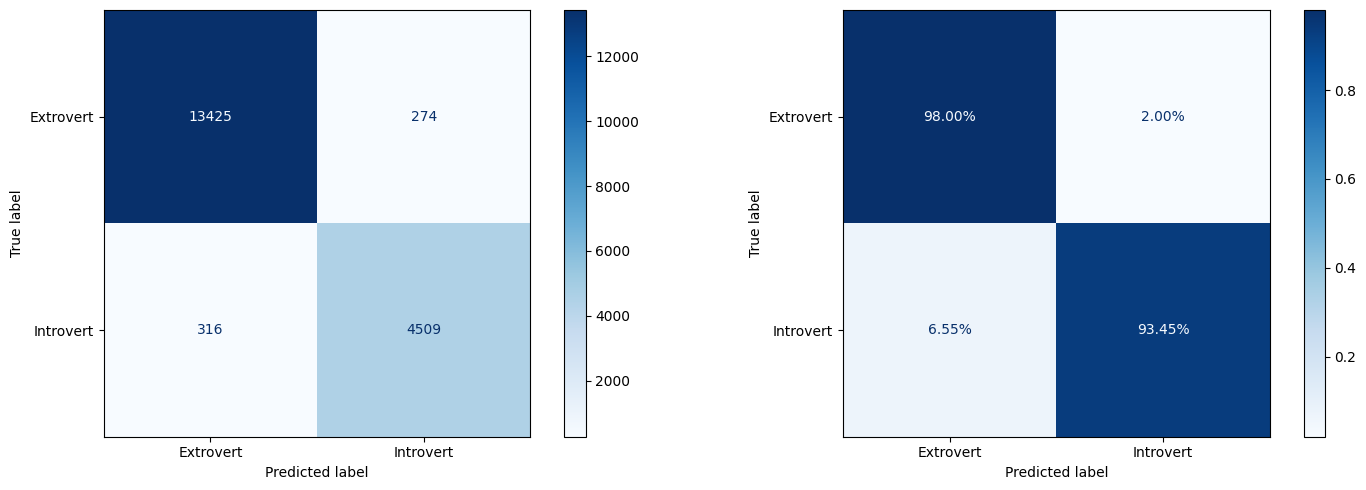

In [25]:
plot_confusion_matrix(y, knn_y_pred)

In [26]:
print(classification_report(y, knn_y_pred))

              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98     13699
   Introvert       0.94      0.93      0.94      4825

    accuracy                           0.97     18524
   macro avg       0.96      0.96      0.96     18524
weighted avg       0.97      0.97      0.97     18524



Avaliação do KNN sem SMOTE.

In [27]:
knn_smote = make_pipeline(KNeighborsClassifier(), preprocessor, sampler)
knn_smote_y_pred = cross_val_predict(knn_smote, X, y, cv=cv, n_jobs=-1)

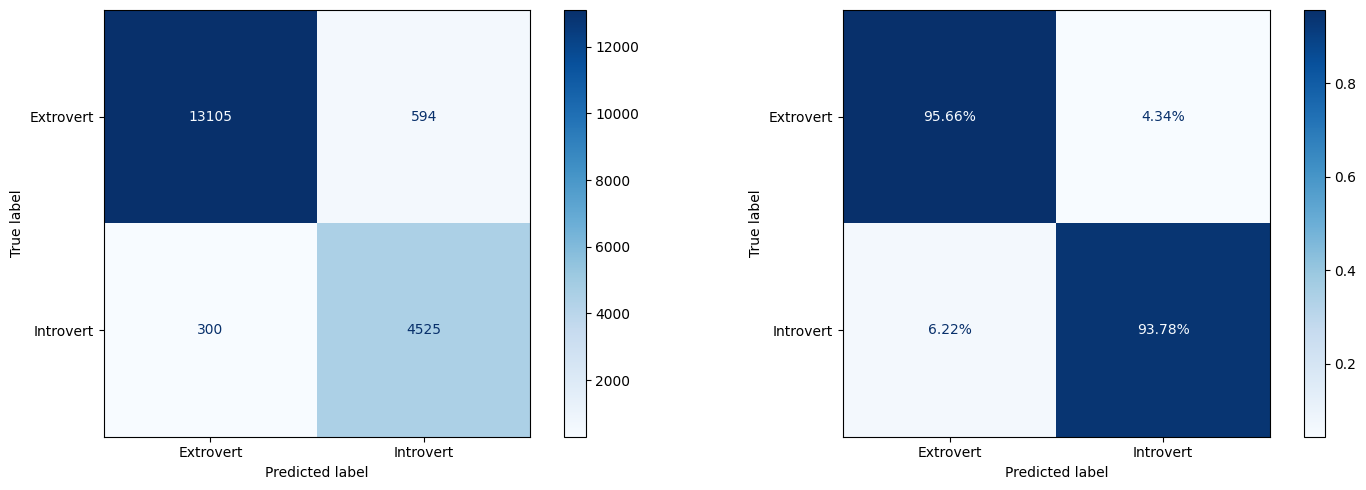

In [28]:
plot_confusion_matrix(y, knn_smote_y_pred)

In [29]:
print(classification_report(y, knn_smote_y_pred))

              precision    recall  f1-score   support

   Extrovert       0.98      0.96      0.97     13699
   Introvert       0.88      0.94      0.91      4825

    accuracy                           0.95     18524
   macro avg       0.93      0.95      0.94     18524
weighted avg       0.95      0.95      0.95     18524



Avaliação do KNN com SMOTE. A precisão da classe minoritária diminuiu, e a revocação da classe minoritária aumentou um pouco. A precisão da classe majoritária permaneceu a mesma, e a revocação da classe majoritária diminuiu um pouco. Acurácia e F1-score diminuíram.

### 4.2. Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
lr = make_pipeline(LogisticRegression(random_state=random_state), preprocessor)
lr_y_pred = cross_val_predict(lr, X, y, cv=cv, n_jobs=-1)

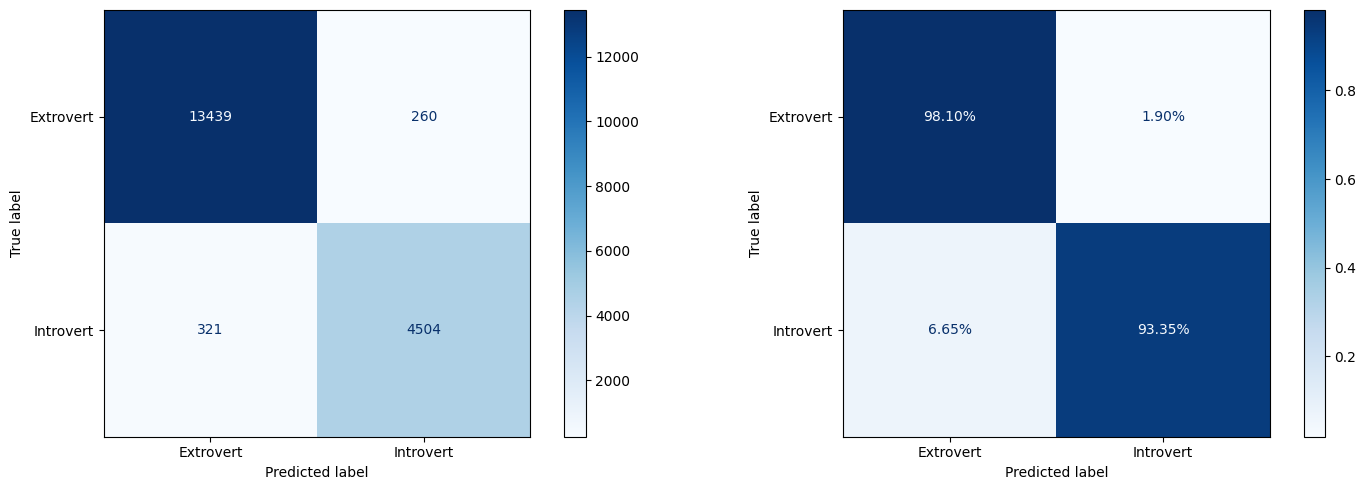

In [32]:
plot_confusion_matrix(y, lr_y_pred)

In [33]:
print(classification_report(y, lr_y_pred))

              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98     13699
   Introvert       0.95      0.93      0.94      4825

    accuracy                           0.97     18524
   macro avg       0.96      0.96      0.96     18524
weighted avg       0.97      0.97      0.97     18524



Avaliação da Logistic Regression sem SMOTE.

In [34]:
lr_smote = make_pipeline(LogisticRegression(random_state=random_state), preprocessor, sampler)
lr_smote_y_pred = cross_val_predict(lr_smote, X, y, cv=cv, n_jobs=-1)

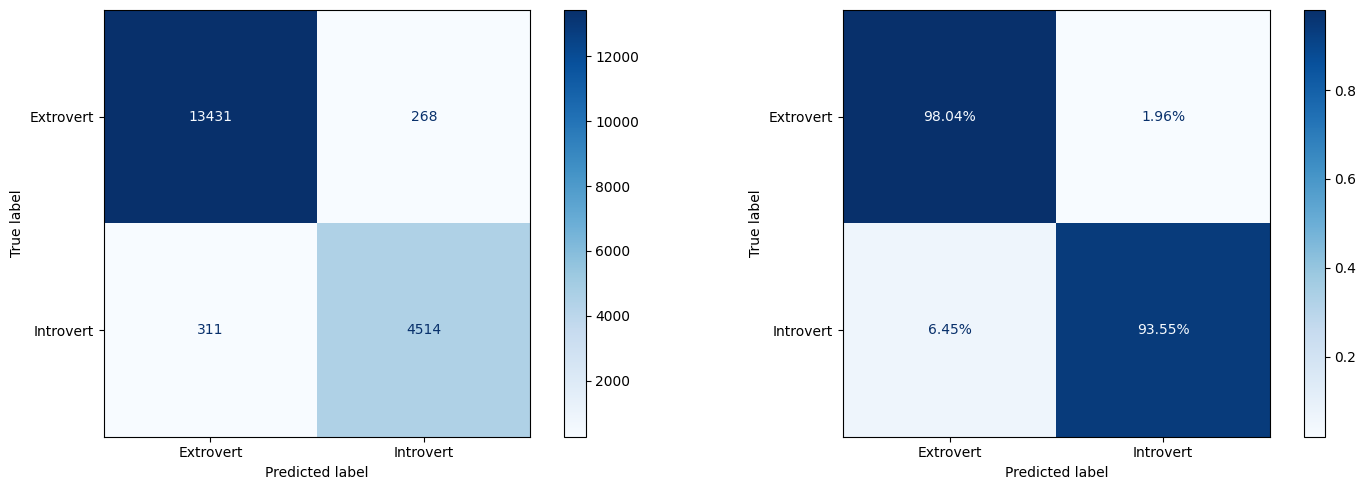

In [35]:
plot_confusion_matrix(y, lr_smote_y_pred)

In [36]:
print(classification_report(y, lr_smote_y_pred))

              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98     13699
   Introvert       0.94      0.94      0.94      4825

    accuracy                           0.97     18524
   macro avg       0.96      0.96      0.96     18524
weighted avg       0.97      0.97      0.97     18524



Avaliação da Logistic Regression com SMOTE. Também trocou um pouco de precisão por revocação na classe minoritária. Não houve alteração na classe majoritária. Acurácia e F1-score se mantiveram iguais.

### 4.3. Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf = make_pipeline(RandomForestClassifier(random_state=random_state), preprocessor)
rf_y_pred = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1)

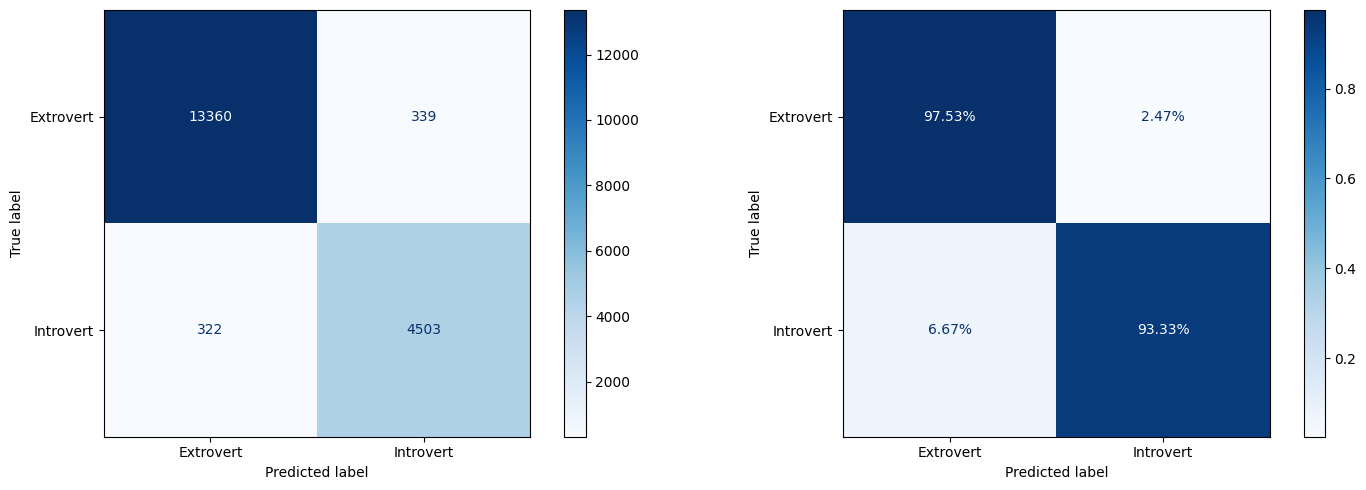

In [39]:
plot_confusion_matrix(y, rf_y_pred)

In [40]:
print(classification_report(y, rf_y_pred))

              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98     13699
   Introvert       0.93      0.93      0.93      4825

    accuracy                           0.96     18524
   macro avg       0.95      0.95      0.95     18524
weighted avg       0.96      0.96      0.96     18524



Avaliação da Random Forest sem SMOTE.

In [41]:
rf_smote = make_pipeline(RandomForestClassifier(random_state=random_state), preprocessor, sampler)
rf_smote_y_pred = cross_val_predict(rf_smote, X, y, cv=cv, n_jobs=-1)

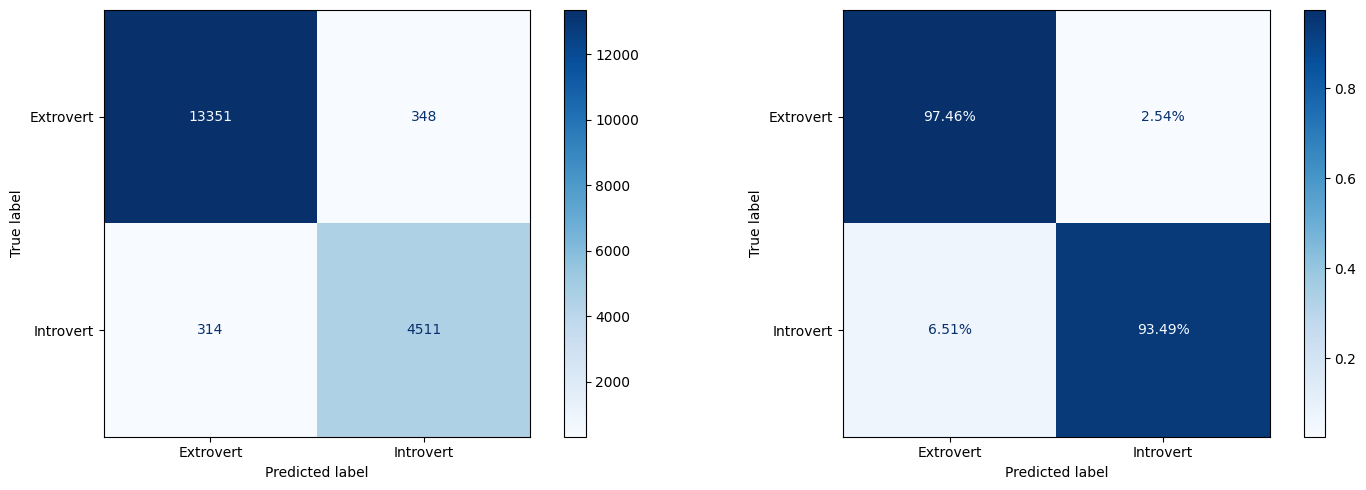

In [42]:
plot_confusion_matrix(y, rf_smote_y_pred)

In [43]:
print(classification_report(y, rf_smote_y_pred))

              precision    recall  f1-score   support

   Extrovert       0.98      0.97      0.98     13699
   Introvert       0.93      0.93      0.93      4825

    accuracy                           0.96     18524
   macro avg       0.95      0.95      0.95     18524
weighted avg       0.96      0.96      0.96     18524



Avaliação da Random Forest com SMOTE. Não houve alteração na classe minoritária. A revocação da classe majoritária diminui um pouco. Acurária e F1-score se mantiveram iguais.

## 5. Comparação de modelos

Os modelos serão comparados com base em 30 execuções de cada. Como o SMOTE não trouxe benefício significativo, não será utilizado balanceamento.

### 5.1. Execução repetida

In [44]:
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=random_state)

In [45]:
knn_scores = cross_val_score(make_pipeline(KNeighborsClassifier(), preprocessor), X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"KNN - Median: {np.median(knn_scores):.4f} | Mean: {knn_scores.mean():.4f} | Std: {knn_scores.std():.4f}")

KNN - Median: 0.9589 | Mean: 0.9585 | Std: 0.0030


In [46]:
lr_scores = cross_val_score(make_pipeline(LogisticRegression(), preprocessor), X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"Logistic Regression - Median: {np.median(lr_scores):.4f} | Mean: {lr_scores.mean():.4f} | Std: {lr_scores.std():.4f}")

Logistic Regression - Median: 0.9599 | Mean: 0.9592 | Std: 0.0031


In [47]:
rf_scores = cross_val_score(make_pipeline(RandomForestClassifier(), preprocessor), X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"Random Forest - Median: {np.median(rf_scores):.4f} | Mean: {rf_scores.mean():.4f} | Std: {rf_scores.std():.4f}")

Random Forest - Median: 0.9537 | Mean: 0.9534 | Std: 0.0031


### 5.2. Visualização

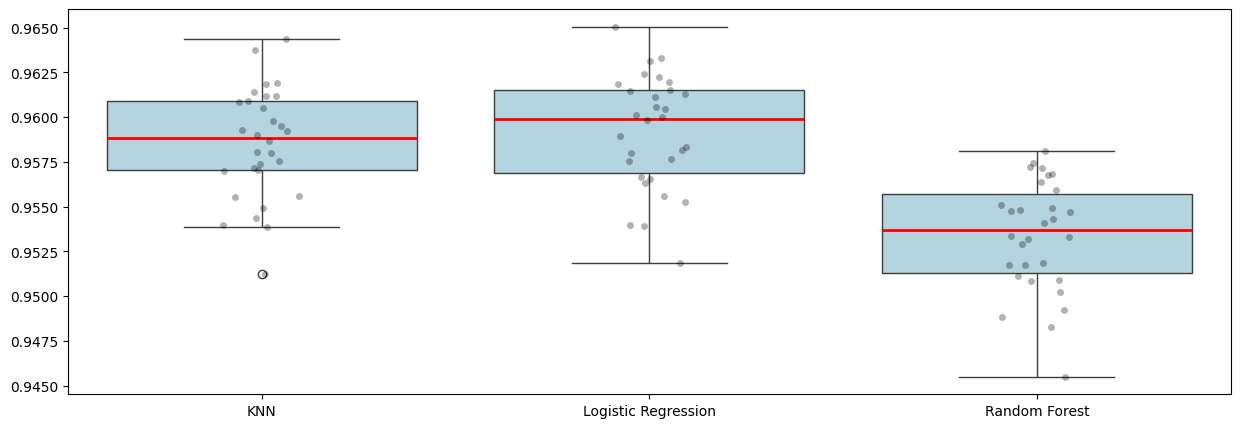

In [48]:
df_results = pd.DataFrame({
    'KNN': knn_scores,
    'Logistic Regression': lr_scores,
    'Random Forest': rf_scores,
})

plt.figure(figsize=(15, 5))

sns.boxplot(
  data=df_results,
  color='lightblue',
  medianprops={'color': 'red', 'linewidth': 2.0}
)
sns.stripplot(data=df_results, color='black', alpha=0.3, jitter=True)

plt.show()

### 5.3. Teste estatístico

In [49]:
from scipy.stats import ttest_rel

stat, p_value = ttest_rel(lr_scores, knn_scores)
print(p_value)
print(p_value < 0.05)

stat, p_value = ttest_rel(lr_scores, rf_scores)
print(p_value)
print(p_value < 0.05)

stat, p_value = ttest_rel(knn_scores, rf_scores)
print(p_value)
print(p_value < 0.05)

1.895744295827344e-05
True
7.685596835069617e-20
True
1.2428837688974453e-18
True


Foi observada diferença estatística significativa entre os desempenhos dos modelos.

## 6. Ajuste de hiperparâmetros

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
  'model__C': [0.001, 0.01, 0.1, 1, 10], # Quanto maior, mais fraca a regularização
  'model__class_weight': [None, 'balanced'] # Testa se vale a pena ponderar classes
}

grid_search = GridSearchCV(
    estimator=make_pipeline(LogisticRegression(), preprocessor),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

Fitting 30 folds for each of 10 candidates, totalling 300 fits


GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=6, n_splits=5, random_state=42),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric_transformer',
                                                                         Pipeline(steps=[('numeric_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('numeric_scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['Time_spent_Alone',
                                                                          'Social_event_attendance',
                                                                          'Going_outside',
                                                                          'Frien...
                                                                        ('categorical_transformer',
                                                                         Pipeline(steps=[('categorical_imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('categorical_encoder',
                                                                                          OneHotEncoder(drop='if_binary'))]),
                                                                         ['Stage_fear',
                                                                          'Drained_after_socializing'])])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10],
                         'model__class_weight': [None, 'balanced']},
             scoring='f1_macro', verbose=1)

In [51]:
print(f"Média Modelo Padrão:  {lr_scores.mean():.4f}")
print(f"Média Modelo Tunado:  {grid_search.best_score_:.4f}")
print(f"Ganho de Performance: {(grid_search.best_score_ - lr_scores.mean()) / lr_scores.mean():.4%}")
print(f"Melhores valores de hiperparâmetros: {grid_search.best_params_}")

Média Modelo Padrão:  0.9592
Média Modelo Tunado:  0.9595
Ganho de Performance: 0.0349%
Melhores valores de hiperparâmetros: {'model__C': 0.01, 'model__class_weight': 'balanced'}


A regularização ficou mais forte que a padrão (1). A ponderação de classe trouxe ganho, ainda que marginal.

## 7. Submissão da tentativa

In [54]:
test_df = pd.read_csv('test.csv', index_col='id')

y = grid_search.best_estimator_.predict(test_df)

submission = pd.DataFrame({
    'id': test_df.index,
    'Personality': y
})

submission.to_csv('submission.csv', index=False)

In [56]:
!kaggle competitions submit -c playground-series-s5e7 -f submission.csv -m "Logistic Regression"

100% 96.5k/96.5k [00:00<00:00, 280kB/s]
Successfully submitted to Predict the Introverts from the Extroverts

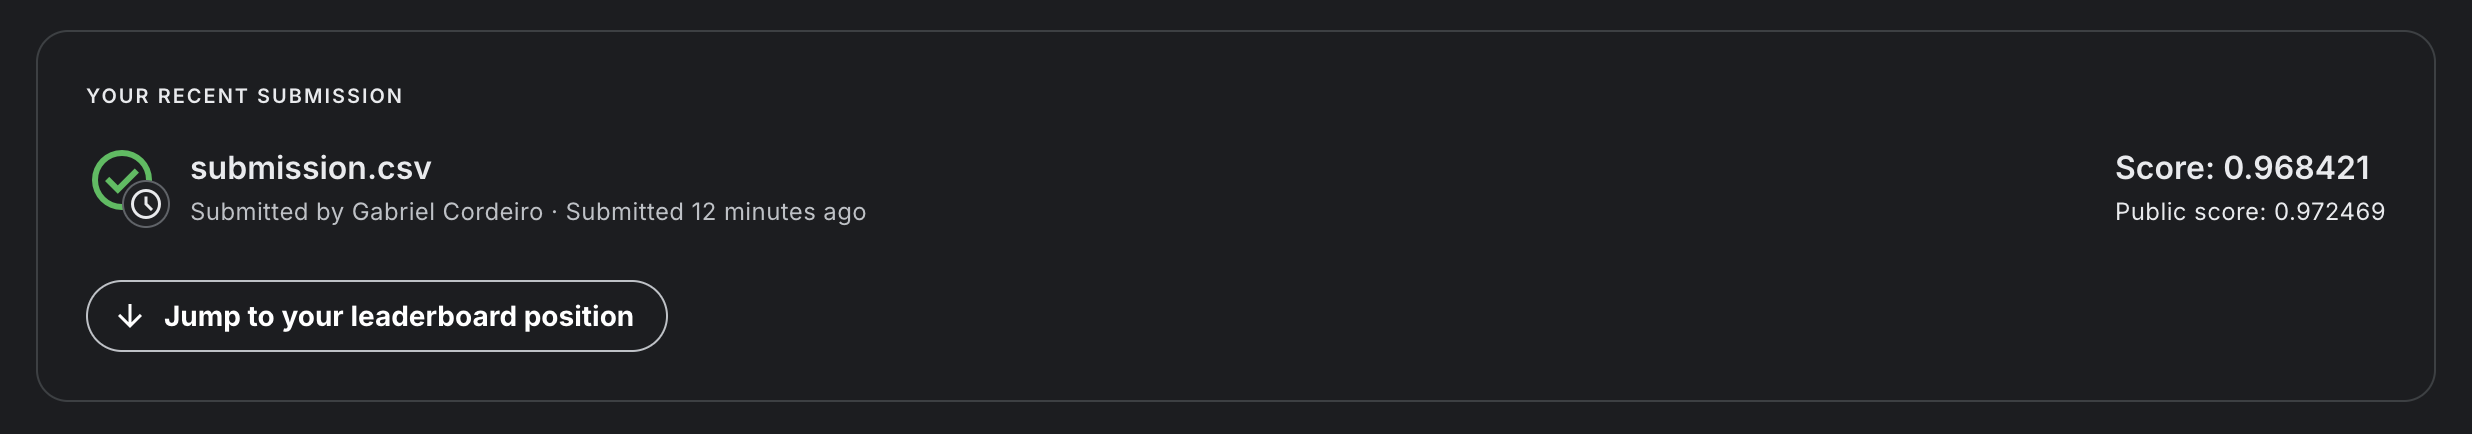